# 9. Gene-Query JEPA — full-run training curves

Inspect the **latest full LPS JEPA run** (not toy).

New runs are stored as:

`.../jepa_gene_query_full_atlas/<spec-name>_{timestamp}/`

with `specs.json`, `checkpoints/`, and `logs/` inside that folder.

The 16 Aug run still sits at the atlas root (no spec subfolder). This notebook picks the newest `specs.json` under the atlas folder, else the newest `metrics.csv`.

**Honesty metric:** `gene_gap_vs_copy_src` must be **> 0**.
Positive = prediction beats copy-source. Loss going down is not enough.

Run top → bottom.


## 9.1 Paths

In [1]:
from pathlib import Path

import json
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import display

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

ATLAS_ROOT = Path(
    "/mnt/sod2-project/csb4/stuke1/perturbgen"
    "/T_perturb/res/jepa_gene_query_full_atlas"
)
GAP_NAME = "gene_gap_vs_copy_src"
PASS_THRESHOLD = 0.05


def resolve_run_dir(atlas_root: Path) -> Path:
    """Newest folder that contains specs.json; else the atlas root."""
    specs = list(atlas_root.rglob("specs.json"))
    if not specs:
        return atlas_root
    return max(specs, key=lambda p: p.stat().st_mtime).parent


def find_metrics_csv(run_dir: Path) -> Path:
    hits = sorted(run_dir.glob("logs/**/metrics.csv")) + sorted(
        run_dir.glob("toy_logs/**/metrics.csv")
    )
    if not hits:
        raise FileNotFoundError(f"no metrics.csv under {run_dir}")
    return max(hits, key=lambda p: p.stat().st_mtime)


RUN_DIR = resolve_run_dir(ATLAS_ROOT)
SPECS_JSON = RUN_DIR / "specs.json"
METRICS_CSV = find_metrics_csv(RUN_DIR)
HPARAMS_YAML = METRICS_CSV.with_name("hparams.yaml")
print("ATLAS_ROOT  ", ATLAS_ROOT)
print("RUN_DIR     ", RUN_DIR)
print("SPECS_JSON  ", SPECS_JSON if SPECS_JSON.is_file() else "(missing)")
print("METRICS_CSV ", METRICS_CSV)


RUN_DIR      /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/jepa_gene_query_full_atlas
METRICS_CSV  /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/jepa_gene_query_full_atlas/logs/20260816_2007_cellgen/version_0/metrics.csv


## 9.2 Load Lightning CSV

CSVLogger writes **two kinds of rows**:
- step rows: `train/*_step` filled, honesty columns empty
- epoch rows: `train/gene_gap_vs_copy_src` filled (one per epoch)

Curves below use the epoch table unless you plot a `_step` column.

In [2]:
raw = pd.read_csv(METRICS_CSV)


def detect_prefix(frame: pd.DataFrame) -> str:
    if frame.get(f"val/{GAP_NAME}") is not None and frame[f"val/{GAP_NAME}"].notna().any():
        return "val"
    if frame.get(f"train/{GAP_NAME}") is not None and frame[f"train/{GAP_NAME}"].notna().any():
        return "train"
    raise ValueError(f"no {GAP_NAME} column with values")


PREFIX = detect_prefix(raw)
GAP = f"{PREFIX}/{GAP_NAME}"

epoch_df = (
    raw[raw[GAP].notna()]
    .copy()
    .sort_values("epoch")
    .drop_duplicates("epoch", keep="last")
    .reset_index(drop=True)
)
step_df = raw.sort_values("step").reset_index(drop=True)

print(f"prefix={PREFIX}  epoch rows={len(epoch_df)}  all rows={len(raw)}")
epoch_df[["epoch", GAP, f"{PREFIX}/gene_cos_pred", f"{PREFIX}/gene_loss"]].head()

prefix=train  epoch rows=20  all rows=946


,epoch,train/gene_gap_vs_copy_src,train/gene_cos_pred,train/gene_loss
0,0,-0.021340,0.767057,0.213405
1,1,-0.018718,0.771649,0.200738
2,2,-0.018686,0.771823,0.200231
3,3,-0.018771,0.771882,0.199939
4,4,-0.018618,0.771936,0.199730


## 9.3 Recipe used for this full run

In [3]:
keys = [
    "freeze_jepa_encoder",
    "jepa_encoder_layers",
    "predictor_layers",
    "n_queries",
    "lambda_gene",
    "lambda_cell",
    "lambda_contrastive",
    "contrastive_temperature",
    "vicreg_var_coeff",
    "vicreg_cov_coeff",
    "lr",
    "pred_tps",
]
if SPECS_JSON.is_file():
    specs = json.loads(SPECS_JSON.read_text())
    print("run_name:", specs.get("run_name"))
    display(pd.json_normalize(specs, sep=".").T.rename(columns={0: "specs.json"}))
elif HPARAMS_YAML.is_file():
    hp = yaml.safe_load(HPARAMS_YAML.read_text())
    display(pd.Series({k: hp.get(k) for k in keys}, name="hparams.yaml"))
else:
    print("no specs.json or hparams.yaml")

freeze_jepa_encoder             True
jepa_encoder_layers                3
predictor_layers                   1
n_queries                         64
lambda_gene                      1.0
lambda_cell                      0.1
lambda_contrastive               0.3
contrastive_temperature          0.1
vicreg_var_coeff                 0.0
vicreg_cov_coeff                 0.0
lr                            0.0001
pred_tps                   [1, 2, 3]
Name: hparams, dtype: object

## 9.4 Honesty verdict

`gene_gap_vs_copy_src` = cosine(pred, target) − cosine(source, target).
If this stays ≤ 0, the model is not beating “copy the source gene embedding”.

In [4]:
gap = epoch_df[GAP]
first, last = float(gap.iloc[0]), float(gap.iloc[-1])
peak = float(gap.max())
peak_ep = int(epoch_df.loc[gap.idxmax(), "epoch"])
passed = last > PASS_THRESHOLD

summary = pd.DataFrame(
    {
        "metric": [GAP, f"{PREFIX}/gene_cos_pred", f"{PREFIX}/gene_loss"],
        "epoch0": [
            first,
            float(epoch_df[f"{PREFIX}/gene_cos_pred"].iloc[0]),
            float(epoch_df[f"{PREFIX}/gene_loss"].iloc[0]),
        ],
        "last": [
            last,
            float(epoch_df[f"{PREFIX}/gene_cos_pred"].iloc[-1]),
            float(epoch_df[f"{PREFIX}/gene_loss"].iloc[-1]),
        ],
    }
)
display(summary.round(4))
print(
    f"gap first={first:+.4f}  peak={peak:+.4f} @ epoch {peak_ep}  "
    f"last={last:+.4f}  threshold={PASS_THRESHOLD}"
)
print("PASS" if passed else "FAIL: gap never clearly above copy-source (full run).")

,metric,epoch0,last
0,train/gene_gap_vs_copy_src,-0.0213,-0.0159
1,train/gene_cos_pred,0.7671,0.7742
2,train/gene_loss,0.2134,0.1974


gap first=-0.0213  peak=-0.0159 @ epoch 19  last=-0.0159  threshold=0.05
FAIL: gap never clearly above copy-source (full run).


## 9.5 Honesty curve

Black dashed line is 0. The model must sit **above** it.

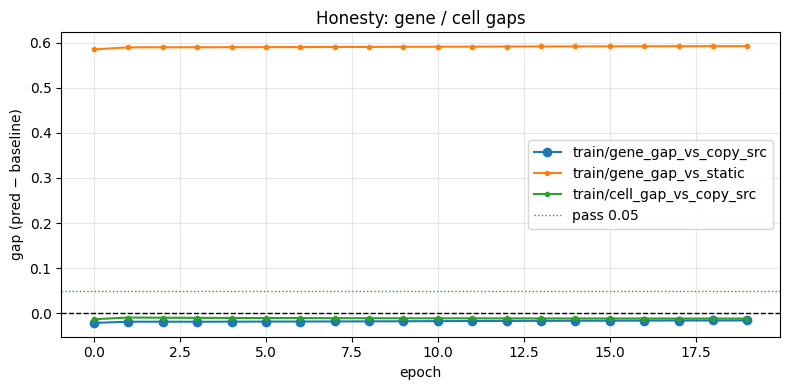

In [5]:
fig, ax = plt.subplots()
ax.plot(epoch_df["epoch"], epoch_df[GAP], marker="o", label=GAP)
if f"{PREFIX}/gene_gap_vs_static" in epoch_df.columns:
    ax.plot(
        epoch_df["epoch"],
        epoch_df[f"{PREFIX}/gene_gap_vs_static"],
        marker=".",
        label=f"{PREFIX}/gene_gap_vs_static",
    )
if f"{PREFIX}/cell_gap_vs_copy_src" in epoch_df.columns:
    ax.plot(
        epoch_df["epoch"],
        epoch_df[f"{PREFIX}/cell_gap_vs_copy_src"],
        marker=".",
        label=f"{PREFIX}/cell_gap_vs_copy_src",
    )
ax.axhline(0.0, color="k", ls="--", lw=1)
ax.axhline(PASS_THRESHOLD, color="C2", ls=":", lw=1, label=f"pass {PASS_THRESHOLD}")
ax.set_xlabel("epoch")
ax.set_ylabel("gap (pred − baseline)")
ax.set_title("Honesty: gene / cell gaps")
ax.legend()
fig.tight_layout()
plt.show()

## 9.6 Losses

`total_loss` can drop while the honesty gap stays negative if contrastive dominates.

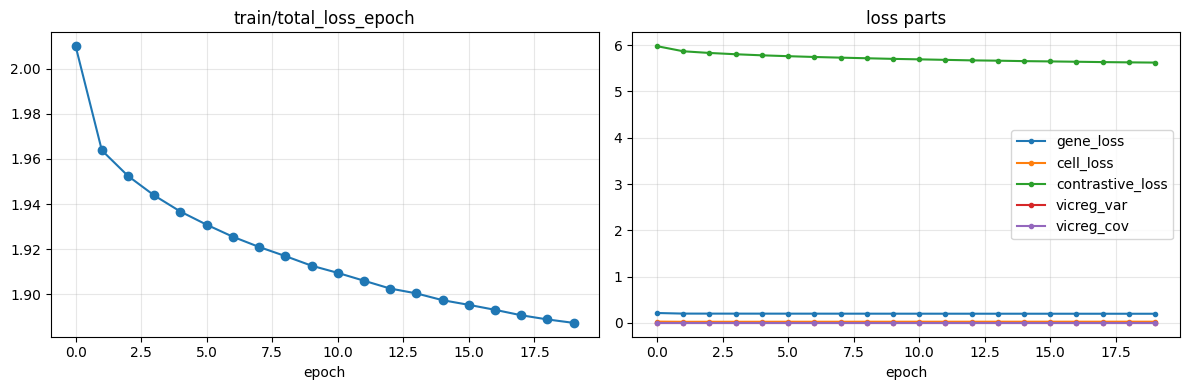

In [6]:
loss_cols = [
    c
    for c in [
        f"{PREFIX}/total_loss_epoch",
        f"{PREFIX}/gene_loss",
        f"{PREFIX}/cell_loss",
        f"{PREFIX}/contrastive_loss",
        f"{PREFIX}/vicreg_var",
        f"{PREFIX}/vicreg_cov",
    ]
    if c in epoch_df.columns and epoch_df[c].notna().any()
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epoch_df["epoch"], epoch_df[loss_cols[0]], marker="o")
axes[0].set_title(loss_cols[0])
axes[0].set_xlabel("epoch")
for col in loss_cols[1:]:
    axes[1].plot(epoch_df["epoch"], epoch_df[col], marker=".", label=col.split("/")[-1])
axes[1].set_title("loss parts")
axes[1].set_xlabel("epoch")
axes[1].legend()
fig.tight_layout()
plt.show()

## 9.7 Cosine (prediction quality, not honesty)

High cosine can still be “copy source”. Pair this plot with §8.5.

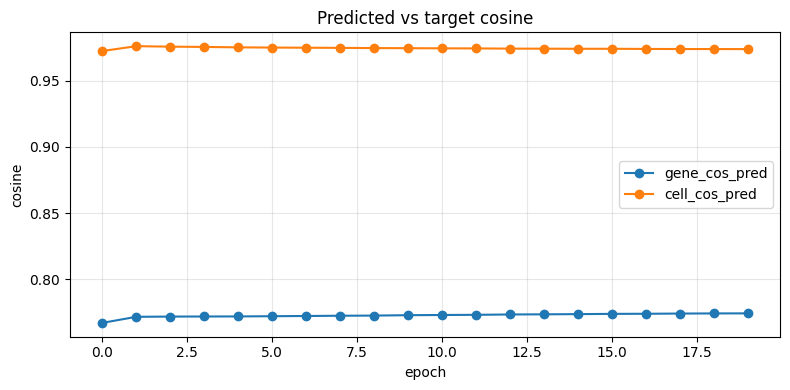

In [7]:
fig, ax = plt.subplots()
for col in [f"{PREFIX}/gene_cos_pred", f"{PREFIX}/cell_cos_pred"]:
    if col in epoch_df.columns:
        ax.plot(epoch_df["epoch"], epoch_df[col], marker="o", label=col.split("/")[-1])
ax.set_xlabel("epoch")
ax.set_ylabel("cosine")
ax.set_title("Predicted vs target cosine")
ax.legend()
fig.tight_layout()
plt.show()

## 9.8 Per-timepoint gene loss

t1 = 90 min, t2 = 6 h, t3 = 10 h.

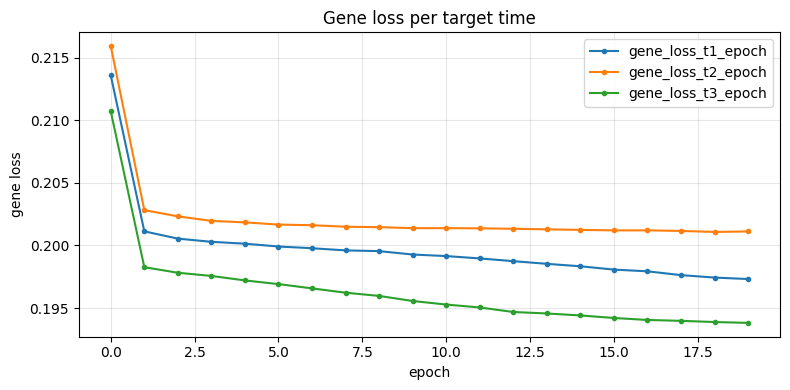

In [8]:
tp_cols = [
    c
    for c in [
        f"{PREFIX}/gene_loss_t1_epoch",
        f"{PREFIX}/gene_loss_t2_epoch",
        f"{PREFIX}/gene_loss_t3_epoch",
    ]
    if c in epoch_df.columns and epoch_df[c].notna().any()
]
fig, ax = plt.subplots()
for col in tp_cols:
    ax.plot(epoch_df["epoch"], epoch_df[col], marker=".", label=col.split("/")[-1])
ax.set_xlabel("epoch")
ax.set_ylabel("gene loss")
ax.set_title("Gene loss per target time")
ax.legend()
fig.tight_layout()
plt.show()

## 9.9 Optional: step-level total loss

Noisy; use if you want to see intra-epoch behaviour.

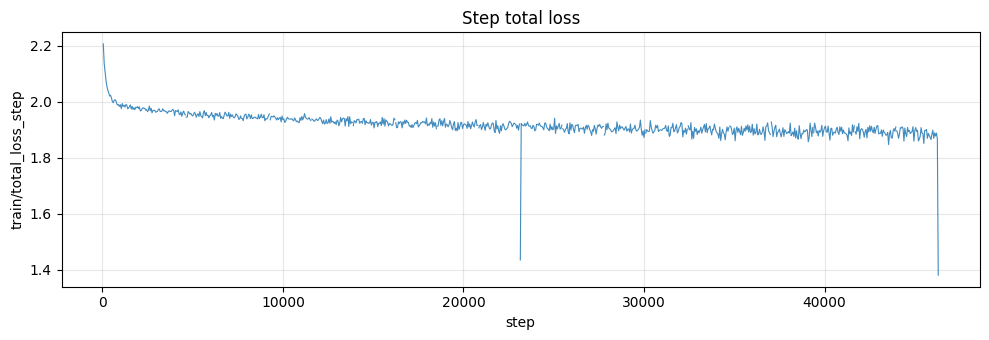

In [9]:
step_col = f"{PREFIX}/total_loss_step"
if step_col in step_df.columns and step_df[step_col].notna().any():
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(step_df["step"], step_df[step_col], lw=0.8, alpha=0.85)
    ax.set_xlabel("step")
    ax.set_ylabel(step_col)
    ax.set_title("Step total loss")
    fig.tight_layout()
    plt.show()
else:
    print("no step total_loss column")

## 9.10 Plot any extra column

Edit `EXTRA` then re-run this cell.

In [10]:
print("epoch columns with data:")
print([c for c in epoch_df.columns if epoch_df[c].notna().any()])

EXTRA = []  # e.g. [f"{PREFIX}/vicreg_var"]
for col in EXTRA:
    fig, ax = plt.subplots()
    ax.plot(epoch_df["epoch"], epoch_df[col], marker="o")
    ax.set_xlabel("epoch")
    ax.set_title(col)
    fig.tight_layout()
    plt.show()

epoch columns with data:
['epoch', 'step', 'train/cell_cos_pred', 'train/cell_gap_vs_copy_src', 'train/cell_loss', 'train/contrastive_loss', 'train/gene_cos_pred', 'train/gene_gap_vs_copy_src', 'train/gene_gap_vs_static', 'train/gene_loss', 'train/gene_loss_t1_epoch', 'train/gene_loss_t2_epoch', 'train/gene_loss_t3_epoch', 'train/total_loss_epoch', 'train/vicreg_cov', 'train/vicreg_var']
